# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [57]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [58]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [59]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [60]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [61]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [62]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Escalonamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [64]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

In [65]:
df = pd.read_csv('aneel_classificacao_orange.csv')
df.head()

df.dtypes
df.info()
df['fonte'].value_counts()
df.isnull().sum()
df.describe()

X = df[['potencia_kw', 'latitude', 'longitude']]
y = df['fonte']

print(X.head())
print(y.head())
print(X.shape)
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB
   potencia_kw   latitude  longitude
0        20.48 -10.442778 -64.151944
1      5000.00  -6.003889 -40.274722
2        12.26 -23.557778 -46.734000
3         3.00 -23.558889 -46.735000
4         1.70 -23.493819 -46.845000
0    Solar
1    Solar
2    Solar
3    Solar
4    Solar
Name: fonte, dtype: object
(3876, 3)
(3876,)


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3100, 3)
X_test: (776, 3)
y_train: (3100,)
y_test: (776,)


In [67]:
modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_scaled, y_train)
modelo_knn = KNeighborsClassifier(n_neighbors=5)

modelo_knn.fit(X_train_scaled, y_train)

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
modelo_rf.fit(X_train_scaled, y_train)

# Justificativa:
# Foram escolhidos três classificadores de características distintas: Regressão
# Logística, K-Nearest Neighbors (KNN) e Random Forest. A Regressão Logística
# representa uma abordagem linear e fornece um modelo simples para classificação.
# O KNN utiliza a proximidade entre as observações e pode identificar padrões
# locais nos dados. Já o Random Forest utiliza múltiplas árvores de decisão e
# consegue modelar relações não lineares. Os três modelos foram treinados
# utilizando a mesma divisão estratificada entre treino e teste, permitindo uma
# comparação posterior mais consistente.

y_pred_logistico = modelo_logistico.predict(X_test_scaled)

y_pred_knn = modelo_knn.predict(X_test_scaled)

y_pred_rf = modelo_rf.predict(X_test_scaled)

In [68]:
modelos = {

    'Regressão Logística': y_pred_logistico,

    'KNN': y_pred_knn,

    'Random Forest': y_pred_rf

}

resultados = []

for nome, y_pred in modelos.items():

    resultados.append({

        'Modelo': nome,

        'Accuracy': accuracy_score(y_test, y_pred),

        'Precision (macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),

        'Recall (macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),

        'F1 (macro)': f1_score(y_test, y_pred, average='macro', zero_division=0)

    })

resultados_df = pd.DataFrame(resultados)

print(resultados_df)

average='macro'

cm_logistico = confusion_matrix(y_test, y_pred_logistico)

print(cm_logistico)

cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

                Modelo  Accuracy  Precision (macro)  Recall (macro)  \
0  Regressão Logística  0.823454           0.827503        0.819970   
1                  KNN  0.966495           0.967727        0.964940   
2        Random Forest  0.975515           0.976881        0.974137   

   F1 (macro)  
0    0.818151  
1    0.966161  
2    0.975252  
[[216  16   8]
 [ 20 257  19]
 [ 55  19 166]]
[[231   6   3]
 [  1 292   3]
 [  5   8 227]]
[[235   4   1]
 [  2 294   0]
 [  5   7 228]]


In [69]:
# O Random Forest foi escolhido por apresentar o maior F1-score macro entre os
# modelos avaliados, indicando melhor equilíbrio entre precisão e recuperação
# das diferentes classes.


In [70]:
modelo_escolhido = modelo_rf

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

import numpy as npclasses
classes = modelo_escolhido.classes_
for i in range(len(classes)):
  for j in range(len(classes)):
    if i != j and cm_rf[i, j] > 0:
      print(                 f"Real: {classes[i]} -> Prevista: {classes[j]}: {cm_rf[i, j]} casos"            )

erros = []
for i in range(len(classes)):
  for j in range(len(classes)):
    if i != j:
      erros.append((cm_rf[i, j], classes[i], classes[j]))

erros = sorted(erros, reverse=True)

print("Principais confusões:")

for quantidade, real, prevista in erros[:5]:
  print(f"{real} -> {prevista}: {quantidade}")

[[235   4   1]
 [  2 294   0]
 [  5   7 228]]
Real: Eólica -> Prevista: Hidráulica: 4 casos
Real: Eólica -> Prevista: Solar: 1 casos
Real: Hidráulica -> Prevista: Eólica: 2 casos
Real: Solar -> Prevista: Eólica: 5 casos
Real: Solar -> Prevista: Hidráulica: 7 casos
Principais confusões:
Solar -> Hidráulica: 7
Solar -> Eólica: 5
Eólica -> Hidráulica: 4
Hidráulica -> Eólica: 2
Eólica -> Solar: 1


In [71]:
# As principais confusões ocorreram entre as classes:
''' Solar -> Hidráulica: 7
Solar -> Eólica: 5
Eólica -> Hidráulica: 4
Hidráulica -> Eólica: 2
Eólica -> Solar: 1.  '''
# Isso indica que, usando apenas potência instalada e localização, essas duas categorias
# apresentam características semelhantes no espaço de atributos utilizado pelo modelo.

' Solar -> Hidráulica: 7\nSolar -> Eólica: 5\nEólica -> Hidráulica: 4\nHidráulica -> Eólica: 2\nEólica -> Solar: 1.  '

In [72]:
# Apesar dos resultados, potência instalada, latitude e longitude podem não ser
# suficientes para uma aplicação real. A potência indica principalmente o porte
# do empreendimento, enquanto a localização fornece informação espacial, mas
# nenhuma das duas identifica diretamente a tecnologia ou o tipo de geração.
# Empreendimentos de fontes diferentes podem apresentar potências semelhantes e
# estar localizados em regiões próximas. Por isso, informações técnicas e operacionais
# adicionais seriam necessárias para uma classificação mais robusta em um cenário real.
# Para evitar que o modelo receba a própria resposta ou informações que a revelem diretamente.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [73]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [74]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [75]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [76]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

Dimensão: (1001, 7)

Tipos das colunas:
data_hora         object
temperatura_c    float64
umidade_pct        int64
nuvens_pct         int64
vento_kmh        float64
hora               int64
radiacao_w_m2    float64
dtype: object

Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64
Dimensão de X: (1001, 5)
Dimensão de y: (1001,)


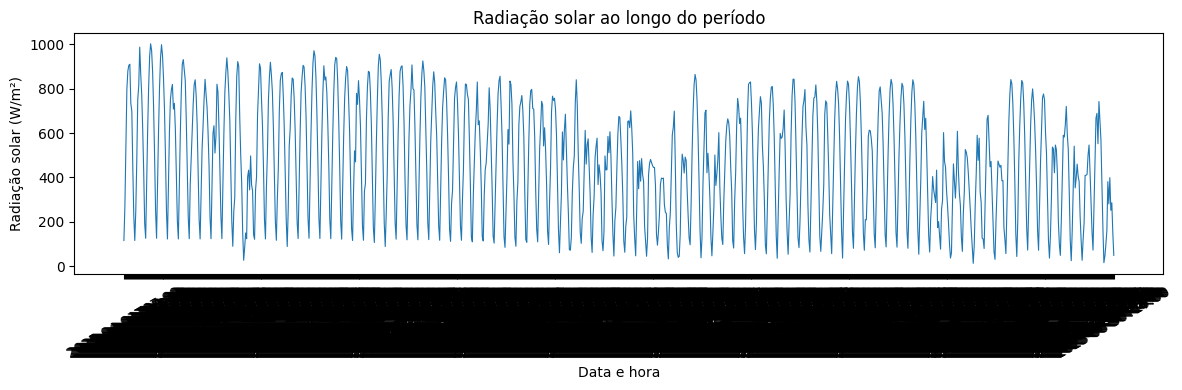

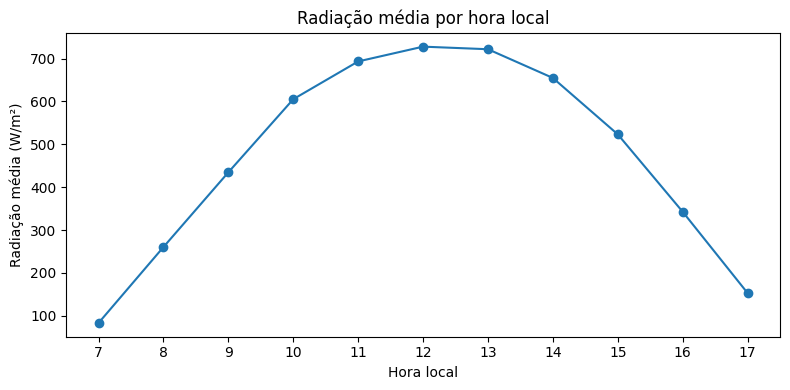

In [77]:
dados = pd.read_csv('meteo_regressao_orange.csv')

print("Dimensão:", dados.shape)
print("\nTipos das colunas:")
print(dados.dtypes)

print("\nValores ausentes:")
print(dados.isna().sum())

colunas_X = [
    "temperatura_c",
    "umidade_pct",
    "nuvens_pct",
    "vento_kmh",
    "hora",
]
coluna_y = "radiacao_w_m2"

X = dados[colunas_X].copy()
y = dados[coluna_y].copy()

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

# Evolução temporal da radiação no período
plt.figure(figsize=(12, 4))
plt.plot(dados["data_hora"], dados["radiacao_w_m2"], linewidth=0.8)
plt.xlabel("Data e hora")
plt.ylabel("Radiação solar (W/m²)")
plt.title("Radiação solar ao longo do período")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Relação entre hora local e radiação média
media_por_hora = dados.groupby("hora", as_index=False)["radiacao_w_m2"].mean()
plt.figure(figsize=(8, 4))
plt.plot(media_por_hora["hora"], media_por_hora["radiacao_w_m2"], marker="o")
plt.xlabel("Hora local")
plt.ylabel("Radiação média (W/m²)")
plt.title("Radiação média por hora local")
plt.xticks(sorted(dados["hora"].unique()))
plt.tight_layout()
plt.show()

In [78]:
n_treino = int(len(dados) * 0.8)

X_train = X.iloc[:n_treino].copy()
X_test = X.iloc[n_treino:].copy()
y_train = y.iloc[:n_treino].copy()
y_test = y.iloc[n_treino:].copy()

print(f"Treino: {len(X_train)} registros ({len(X_train) / len(X):.1%})")
print(f"Teste:  {len(X_test)} registros ({len(X_test) / len(X):.1%})")
print("Último horário do treino:", dados.loc[n_treino - 1, "data_hora"])
print("Primeiro horário do teste:", dados.loc[n_treino, "data_hora"])

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

Treino: 800 registros (79.9%)
Teste:  201 registros (20.1%)
Último horário do treino: 2025-06-12T14:00
Primeiro horário do teste: 2025-06-12T15:00


In [79]:
modelo_linear = LinearRegression()
modelo_arvore = DecisionTreeRegressor(random_state=42)
modelo_floresta = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

modelo_linear.fit(X_train_scaled, y_train)
modelo_arvore.fit(X_train_scaled, y_train)
modelo_floresta.fit(X_train_scaled, y_train)

print("Três modelos treinados com sucesso.")

Três modelos treinados com sucesso.


In [80]:
previsoes = {
    "Regressão Linear": modelo_linear.predict(X_test_scaled),
    "Árvore de Decisão": modelo_arvore.predict(X_test_scaled),
    "Random Forest": modelo_floresta.predict(X_test_scaled),
}

resultados_reg = []
for nome, y_pred in previsoes.items():
    resultados_reg.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_test, y_pred),
        "MSE ((W/m²)²)": mean_squared_error(y_test, y_pred),
        "R²": r2_score(y_test, y_pred),
    })

resultados_reg_df = pd.DataFrame(resultados_reg)
resultados_reg_df = resultados_reg_df.sort_values("MAE (W/m²)").reset_index(drop=True)

display(resultados_reg_df)

print("Critério principal usado para a escolha: menor MAE no conjunto de teste.")
print("O MSE deve ser o menor possível e o R², o maior possível.")

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Random Forest,66.123234,7214.689436,0.846225
1,Árvore de Decisão,87.631841,15146.975124,0.677154
2,Regressão Linear,145.204885,30034.201092,0.359845


Critério principal usado para a escolha: menor MAE no conjunto de teste.
O MSE deve ser o menor possível e o R², o maior possível.


Modelo escolhido pelo menor MAE: Random Forest


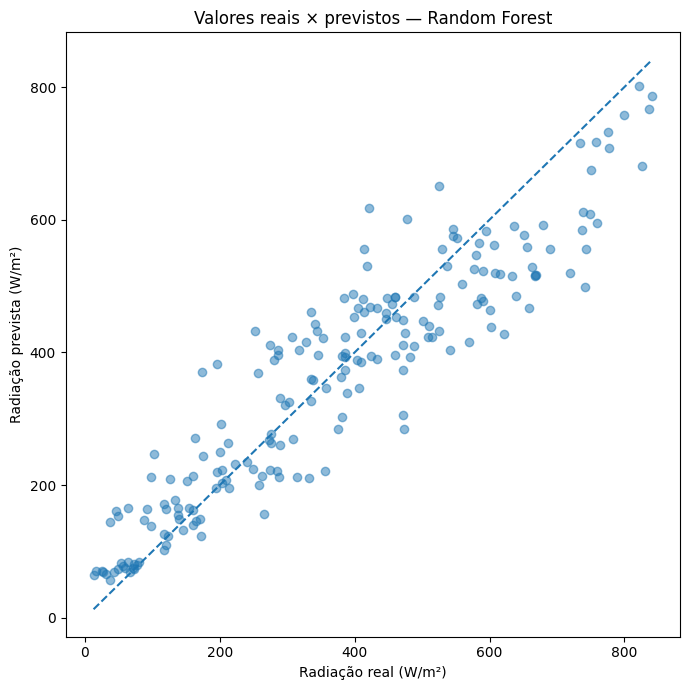

In [81]:
nome_escolhido = resultados_reg_df.iloc[0]["Modelo"]
pred_escolhida = previsoes[nome_escolhido]

print("Modelo escolhido pelo menor MAE:", nome_escolhido)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_escolhida, alpha=0.5)

limite_min = min(y_test.min(), pred_escolhida.min())
limite_max = max(y_test.max(), pred_escolhida.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], linestyle="--")

plt.xlabel("Radiação real (W/m²)")
plt.ylabel("Radiação prevista (W/m²)")
plt.title(f"Valores reais × previstos — {nome_escolhido}")
plt.tight_layout()
plt.show()

In [82]:
importancias = pd.Series(
    modelo_floresta.feature_importances_,
    index=colunas_X
).sort_values(ascending=False)

print("Importância das variáveis segundo a Random Forest:")
display(importancias.to_frame("importância"))

Importância das variáveis segundo a Random Forest:


,importância
hora,0.487927
temperatura_c,0.295213
umidade_pct,0.179311
nuvens_pct,0.021653
vento_kmh,0.015897


In [83]:
# A comparação deve considerar as três métricas. MAE está em W/m² e indica, em
# média, quanto a previsão se afasta do valor real. MSE penaliza mais fortemente
# erros grandes e é expresso em (W/m²)². R² mede a proporção da variabilidade do
# alvo explicada pelo modelo em relação à referência de usar a média do treino;
# Para esta tarefa, o modelo de referência é selecionado pelo menor MAE no teste.
# A tabela também deve ser observada com MSE e R² para verificar se a conclusão é consistente.
# A variável hora é potencialmente importante porque representa a posição do registro
# dentro do ciclo diário de radiação: a disponibilidade de radiação varia fortemente
# ao longo do dia. Isso faz com que hora funcione como um indicador temporal útil para o modelo.
# A tabela de importância da Random Forest ajuda a verificar o quanto essa entrada foi
# utilizada pelo modelo; importância de variável é uma associação do modelo,
# não prova de causalidade.
# Mesmo com boas métricas, a estimativa de radiacao_w_m2 não equivale à previsão
# de energia elétrica produzida por um sistema fotovoltaico. A radiação é um recurso
# ambiental; a energia gerada também depende, entre outros fatores, das características
# e eficiência dos módulos, orientação e inclinação, perdas do sistema, disponibilidade
# operacional, temperatura dos equipamentos e demais condições do empreendimento.
# Portanto, seria necessário um modelo adicional específico de geração elétrica para estimar energia produzida.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)